# Chapter 16 — We Found an Individual. Then We Didn't.

## Book linkage

- **Current chapter:** [`16-we-found-an-individual-then-we-didnt.md`](../content/books/digital-life/16-we-found-an-individual-then-we-didnt.md)
- **Claims supported:** DL-16-C01 .. DL-16-C05 (see `NOTEBOOK_MIGRATION.md`)
- **Historical sources:** original book Chapter 28 ("Does a Causal Individual Emerge? / Containment Is Not
  Individuation"), two-version chain `research/digital-life/ch28-causal-modularity-v1/` (raw causal-modularity
  measurement, verdict `CAUSAL_MODULARITY_SUPPORTED`) and `research/digital-life/ch28-causal-modularity-v2/`
  (adds a same-checkpoint geometry-matched null, verdict `EXCESS_CAUSAL_MODULARITY_BOUNDED_BELOW_SEI`,
  explicitly `V1_status_preserved: RAW_CAUSAL_MODULARITY_SUPPORTED`). Also `ch28_causal_modularity_overlap_audit.py`
  (folded into V2 as `stage-07-spatial-overlap-audit`), a post-hoc robustness check on the matched-null result.
  Scripts: `ch28_digital_crystal_causal_modularity_v1.py`, `_v2.py`, `ch28_causal_modularity_overlap_audit.py`.
- **Legacy notebook:** `notebooks_original/28-containment-is-not-individuation.ipynb` — a **pure-audit notebook**
  (asserts against precomputed JSON, no live computation). This notebook is a deliberate **upgrade** from that
  pattern to genuine live recompute, per the migration matrix's instruction for this headline chapter.

This notebook tells the chapter's own two-stage story in order: first it measures raw causal modularity
exactly as V1 did (a candidate region's internal causal retention minus its external causal penetration,
against a frozen absolute threshold) — and finds it strongly positive. Then it asks the harder question V2
asked: is that positive number privileged relative to an ordinary same-checkpoint patch of crystal of matched
geometry, or is it just what *any* region that shape and size would show? V1's raw measurement is not
overturned by V2 — it is narrowed. Both stages are run live here, at reduced scale, directly against
`_shared/digital_crystal.py` and `_shared/crystal_causal.py`'s FORCE/PREVENT/CRN machinery (built for
Chapter 13 and explicitly designed for reuse through Chapter 16 — see that module's own docstring).

**Deliberate scope simplification, disclosed up front:** the canonical `ch28` pipeline builds its checkpoints
through the full Chapter 18/21/24/27 dependency chain (persistent material state, finite evaluation budget,
frontier-creation causal gain, decaying material history). This notebook reuses `crystal_causal.py`'s explicit
simplification instead (see that module's docstring): it operates directly on the plain
`digital-crystal-v1-frozen` substrate, with no material-history layer and no finite-budget candidate selector.
Chapter 28's own V1 protocol requires **true unbounded evaluation** ("all current frontier candidates are
evaluated") specifically to remove the Chapter 25 finite-budget confound — `_shared/digital_crystal.py`'s
`frontier()` already evaluates every candidate with no selector, so this simplification is not a deviation
from V1's own design; it is what V1's own protocol already asked for.

## Question

Does a predeclared spatial region of the Digital Crystal behave as a **causal module** — internally
initiated perturbations retained inside the region more strongly than equivalently local externally
initiated perturbations penetrate it — by a predeclared meaningful margin? And if so, is that a privileged
property of *this* region, or would an ordinary same-checkpoint region of matched geometry show the same
thing?

## Hypotheses

- **H1 (raw modularity, V1):** at a frozen primary radius, mean `MODULE_SCORE = internal_retention -
  external_penetration` exceeds the frozen `MODULE_SEI = 0.15` margin.
- **H1b (scale diagnostic, V1, descriptive):** does `MODULE_SCORE` peak at a finite spatial scale, or rise
  monotonically with radius with no characteristic scale? (A pure monotonic rise with no peak is a
  *warning sign*, not confirmation, that the effect is locality-only rather than boundary-specific.)
- **H2 (excess modularity over a matched null, V2):** the *excess* of an observed region's `MODULE_SCORE`
  over a same-checkpoint, outcome-blind, geometry-matched control region's `MODULE_SCORE` exceeds the frozen
  `EXCESS_SEI = 0.10` margin.
- **H2b (spatial-overlap robustness, post-hoc):** does restricting matched pairs to spatially distinct
  (non-overlapping) regions move the excess estimate toward positive privilege?

## Claim boundary

This experiment can establish or bound whether a candidate region is a **causal module** under this specific
operational test (absolute causal mass, FORCE/PREVENT probes, H=8 horizon, fixed-radius hex disks). It
cannot establish, and explicitly does not claim: organism, self, agent, autonomy, biological individual,
homeostasis, reproduction, metabolism, or life. A supported causal module is at most a necessary ingredient
for a stronger individuality claim, never a complete one — and (this chapter's central finding) even the
necessary ingredient does not survive being compared to an ordinary patch of the same crystal.

In [1]:
import sys, json, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

NB_DIR = Path.cwd() if (Path.cwd() / "_shared").exists() else Path.cwd().parent
sys.path.insert(0, str(NB_DIR / "_shared"))
REPO_ROOT = NB_DIR.parent

from digital_crystal import CrystalParams, frontier, attachment_probability, hex_distance
from crystal_causal import make_environment, warm_checkpoint, crn_step, occupied_neighbor_count

FIG_DIR = NB_DIR / "generated-figures"
FIG_DIR.mkdir(exist_ok=True)
print("Shared modules loaded from:", NB_DIR / "_shared")

Shared modules loaded from: C:\Projects\digital-life\notebooks\_shared


## Model / system

Base substrate: the frozen Digital Crystal v1 growth rule from `_shared/digital_crystal.py` (hexagonal
lattice, stochastic attachment via the same logistic rule used throughout the suite). No loss rule, no
finite budget, no material-history trace — see the scope note above.

**Candidate region:** a fixed-radius axial hex disk `R(center, radius)` centered on an occupied cell, chosen
*before* any causal outcome is computed (outcome-blind), subject to occupancy-support gates (minimum occupied
count, occupancy fraction not near-empty/near-full, minimum internal/external frontier-probe support).

**Probes:** frontier cells with exactly one occupied neighbour (`n=1`), matching the geometry used
throughout Chapters 13-15. **Internal probes** lie inside the region; **external-shell probes** lie just
outside the region boundary (within one hex ring).

**Causal mass:** for a probe `x`, build a CRN-coupled FORCE branch (`x` forced occupied for exactly one
growth exposure, then removed — reusing the same "one full causal update, then removed" TRANSIENT semantics
`crystal_causal.py` built for Chapter 13) and a PREVENT branch (`x` excluded from the candidate set at that
one exposure). At each of `H` subsequent lags, before either branch is advanced, compute
`delta_p(y) = P_FORCE(attach y) - P_PREVENT(attach y)` for every frontier cell `y != x` of either branch, and
accumulate `|delta_p(y)|` into "inside region" or "outside region" depending on whether `y` lies in the
candidate region. `internal_retention` / `external_penetration` = mean, over a probe class, of
`inside_mass / (inside_mass + outside_mass)`. `MODULE_SCORE = internal_retention - external_penetration`.

In [2]:
PARAMS = CrystalParams()

EXPERIMENT = {
    "base_seed": 20260916,        # matches the canonical ch28 fresh-seed default exactly
    "world_radius": 26,           # canonical full profile used 110; reduced here for interactive runtime (disclosed)
    "warmup_steps": 12,           # canonical full profile used 24-28; reduced here (disclosed)
    "horizon": 8,                 # matches canonical H=8 exactly
    "groups": 32,                 # canonical full profile used 192 independent groups; reduced here (disclosed)
    "region_radii": [2, 3, 4, 5], # matches canonical REGION_RADII exactly
    "primary_radius": 4,          # matches canonical PRIMARY_REGION_RADIUS exactly
    "regions_per_group": 2,       # canonical used 3; reduced here (disclosed)
    "k_internal": 3,              # matches canonical K_INTERNAL exactly
    "k_external": 3,              # matches canonical K_EXTERNAL exactly
    "min_occupied_in_region": 12, # matches canonical MIN_OCCUPIED_IN_REGION exactly
    "min_internal_probes": 2,     # matches canonical MIN_INTERNAL_FRONTIER_PROBES exactly
    "min_external_probes": 2,     # matches canonical MIN_EXTERNAL_FRONTIER_PROBES exactly
    "module_sei": 0.15,           # matches canonical MODULE_SEI exactly
    "excess_sei": 0.10,           # matches canonical V2 EXCESS_SEI exactly
    "controls_per_observed": 2,   # matches canonical controls_per_observed exactly
    # Matched-null tolerances (canonical V2 used 8 geometry features; this notebook uses the 3 cheapest of
    # those -- occupancy fraction, radial distance, occupied count -- with the *same* tolerances. Disclosed
    # simplification, not a reproduction of the full 8-feature match.)
    "max_occupancy_diff": 0.08,
    "max_radial_diff": 6,
    "max_occupied_count_diff": 8,
}
EXPERIMENT

{'base_seed': 20260916,
 'world_radius': 26,
 'warmup_steps': 12,
 'horizon': 8,
 'groups': 32,
 'region_radii': [2, 3, 4, 5],
 'primary_radius': 4,
 'regions_per_group': 2,
 'k_internal': 3,
 'k_external': 3,
 'min_occupied_in_region': 12,
 'min_internal_probes': 2,
 'min_external_probes': 2,
 'module_sei': 0.15,
 'excess_sei': 0.1,
 'controls_per_observed': 2,
 'max_occupancy_diff': 0.08,
 'max_radial_diff': 6,
 'max_occupied_count_diff': 8}

## Experimental design 1 — V1 raw causal modularity at the frozen primary radius (H1)

For each of `groups` independent checkpoints, build all outcome-blind candidate regions at
`primary_radius = 4`, rank them (occupancy fraction closest to 0.50, then radial distance, then axial
coordinates -- exactly V1's deterministic, non-maximizing selection rule) and keep the top
`regions_per_group`. For each selected region, probe `k_internal` internal and `k_external` external-shell
frontier cells and compute `MODULE_SCORE`. Aggregate first within region, then within group, then bootstrap
across independent groups.

In [3]:
def axial_distance(a, b):
    dq = a[0] - b[0]
    dr = a[1] - b[1]
    return max(abs(dq), abs(dr), abs(dq + dr))


def hex_disk(center, radius):
    cq, cr = center
    cells = set()
    for dq in range(-radius, radius + 1):
        for dr in range(-radius, radius + 1):
            c = (cq + dq, cr + dr)
            if axial_distance(center, c) <= radius:
                cells.add(c)
    return cells


def frontier_n1_probes(occupied, world_radius, cells):
    """Frontier cells inside `cells` with exactly one occupied neighbour -- the
    same n=1 probe geometry used throughout Chapters 13-15."""
    candidates = frontier(occupied, world_radius) & cells
    return [c for c in sorted(candidates) if occupied_neighbor_count(occupied, c) == 1]


def build_candidate_regions(occupied, region_radius, world_radius, exp):
    """Outcome-blind candidate hex-disk regions: geometry and probe support only,
    no causal outcome is computed before selection (matches V1's non-maximizing design)."""
    out = []
    for center in sorted(occupied):
        cells = hex_disk(center, region_radius)
        occ_count = len(cells & occupied)
        occ_frac = occ_count / len(cells)
        if occ_count < exp["min_occupied_in_region"]:
            continue
        if not (0.20 <= occ_frac <= 0.80):
            continue
        internal = frontier_n1_probes(occupied, world_radius, cells)
        shell = hex_disk(center, region_radius + 1) - cells
        external = frontier_n1_probes(occupied, world_radius, shell)
        if len(internal) < exp["min_internal_probes"] or len(external) < exp["min_external_probes"]:
            continue
        out.append(dict(
            center=center, radius=region_radius, cells=cells,
            occupied_count=occ_count, occupancy_fraction=occ_frac,
            internal_frontier=internal, external_frontier=external,
            center_radial_distance=hex_distance(center),
        ))
    out.sort(key=lambda r: (abs(r["occupancy_fraction"] - 0.50), r["center_radial_distance"], r["center"]))
    return out

In [4]:
def region_probe_mass(occupied, birth_time, step, env, region_cells, x, world_radius, params, seed, horizon):
    """Rao-Blackwellized expected causal mass for one probe `x`, partitioned into
    'inside region' vs 'outside region, within H hex-steps of x' vs 'far'. Reuses
    `crystal_causal.crn_step` (cell-keyed common random numbers) so FORCE and PREVENT
    branches diverge only because of the intervention, never because of independent luck.
    """
    force_occ = set(occupied) | {x}
    force_bt = dict(birth_time)
    force_bt.setdefault(x, step)
    prevent_occ = set(occupied) - {x}
    prevent_bt = {k: v for k, v in birth_time.items() if k != x}

    abs_inside = 0.0
    abs_outside = 0.0
    far_max = 0.0
    cur_step = step

    for lag in range(1, horizon + 1):
        input_value = float(env[lag - 1])
        ff = frontier(force_occ, world_radius)
        pf = frontier(prevent_occ, world_radius)
        for cell in (ff | pf):
            if cell == x:
                continue
            p_force = attachment_probability(cell, force_occ, input_value, params) if cell in ff else 0.0
            p_prevent = attachment_probability(cell, prevent_occ, input_value, params) if cell in pf else 0.0
            delta = p_force - p_prevent
            if cell in region_cells:
                abs_inside += abs(delta)
            else:
                d = axial_distance(cell, x)
                if d <= horizon:
                    abs_outside += abs(delta)
                else:
                    far_max = max(far_max, abs(delta))
        excluded = [x] if lag == 1 else []
        force_occ, force_bt, _ = crn_step(force_occ, force_bt, cur_step, input_value, world_radius, params, seed)
        prevent_occ, prevent_bt, _ = crn_step(
            prevent_occ, prevent_bt, cur_step, input_value, world_radius, params, seed, excluded=excluded
        )
        cur_step += 1
        if lag == 1:
            force_occ.discard(x); force_bt.pop(x, None)
            prevent_occ.discard(x); prevent_bt.pop(x, None)

    denom = abs_inside + abs_outside
    inside_fraction = abs_inside / denom if denom > 0 else float("nan")
    return inside_fraction, abs_inside, abs_outside, far_max


def region_module_score(region, occupied, birth_time, step, env, world_radius, params, seed_base, horizon, k_i, k_e):
    internal_probes = region["internal_frontier"][:k_i]
    external_probes = region["external_frontier"][:k_e]
    ints, exts = [], []
    far_max = 0.0
    for i, x in enumerate(internal_probes):
        frac, _, _, fm = region_probe_mass(occupied, birth_time, step, env, region["cells"], x, world_radius, params, seed_base + 1000 + i, horizon)
        ints.append(frac); far_max = max(far_max, fm)
    for i, x in enumerate(external_probes):
        frac, _, _, fm = region_probe_mass(occupied, birth_time, step, env, region["cells"], x, world_radius, params, seed_base + 2000 + i, horizon)
        exts.append(frac); far_max = max(far_max, fm)
    internal_retention = float(np.mean(ints))
    external_penetration = float(np.mean(exts))
    return dict(
        internal_retention=internal_retention,
        external_penetration=external_penetration,
        module_score=internal_retention - external_penetration,
        far_max=far_max,
        n_internal=len(ints), n_external=len(exts),
    )


def find_matched_controls(observed, pool, exp, n_controls):
    """Same-checkpoint, outcome-blind matched controls: any other candidate region in
    the same radius-4 pool within tolerance on occupancy fraction / radial distance /
    occupied count (the 3 cheapest of V2's 8 matching features -- disclosed simplification),
    ranked by standardized distance across those 3 features, closest first."""
    cands = []
    for r in pool:
        if r["center"] == observed["center"]:
            continue
        if abs(r["occupancy_fraction"] - observed["occupancy_fraction"]) > exp["max_occupancy_diff"]:
            continue
        if abs(r["center_radial_distance"] - observed["center_radial_distance"]) > exp["max_radial_diff"]:
            continue
        if abs(r["occupied_count"] - observed["occupied_count"]) > exp["max_occupied_count_diff"]:
            continue
        d = (
            ((r["occupancy_fraction"] - observed["occupancy_fraction"]) / exp["max_occupancy_diff"]) ** 2
            + ((r["center_radial_distance"] - observed["center_radial_distance"]) / exp["max_radial_diff"]) ** 2
            + ((r["occupied_count"] - observed["occupied_count"]) / exp["max_occupied_count_diff"]) ** 2
        )
        cands.append((d, r))
    cands.sort(key=lambda t: (t[0], t[1]["center"]))
    return [r for _, r in cands[:n_controls]]


def bootstrap_ci(values, n_boot=4000, seed=0, alpha=0.05):
    rng = np.random.default_rng(seed)
    values = np.asarray(values, dtype=float)
    n = len(values)
    boot_means = np.array([rng.choice(values, size=n, replace=True).mean() for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)

In [5]:
exp = EXPERIMENT
t0 = time.time()

scale_sweep_scores = {r: [] for r in exp["region_radii"]}   # per-region module scores, all radii (H1b)
primary_group_scores = []                                    # per-group mean module score at radius 4 (H1)
group_excess = []                                             # per-group mean excess over matched null (H2)
overlap_pairs = []                                            # (center_dist, disk_overlap_frac, excess) per matched pair
far_assertion_max = 0.0

for g in range(exp["groups"]):
    seed_base = exp["base_seed"] + g * 131
    env = make_environment(exp["warmup_steps"] + exp["horizon"] + 4, seed_base + 1)
    state = warm_checkpoint(env, exp["warmup_steps"], seed_base + 2, exp["world_radius"], PARAMS)
    future_env = env[exp["warmup_steps"]: exp["warmup_steps"] + exp["horizon"]]

    # -- secondary radii: descriptive scale sweep only --
    for R in exp["region_radii"]:
        if R == exp["primary_radius"]:
            continue
        cands = build_candidate_regions(state.occupied, R, exp["world_radius"], exp)
        for region in cands[: exp["regions_per_group"]]:
            res = region_module_score(
                region, state.occupied, state.birth_time, state.step, future_env,
                exp["world_radius"], PARAMS, seed_base + R * 10000, exp["horizon"], exp["k_internal"], exp["k_external"],
            )
            scale_sweep_scores[R].append(res["module_score"])
            far_assertion_max = max(far_assertion_max, res["far_max"])

    # -- primary radius 4: raw modularity (H1) + matched null (H2) --
    pool4 = build_candidate_regions(state.occupied, exp["primary_radius"], exp["world_radius"], exp)
    observed4 = pool4[: exp["regions_per_group"]]
    group_primary_scores = []
    group_excess_vals = []
    for oi, obs in enumerate(observed4):
        obs_res = region_module_score(
            obs, state.occupied, state.birth_time, state.step, future_env,
            exp["world_radius"], PARAMS, seed_base + 40000 + oi * 100, exp["horizon"], exp["k_internal"], exp["k_external"],
        )
        scale_sweep_scores[exp["primary_radius"]].append(obs_res["module_score"])
        group_primary_scores.append(obs_res["module_score"])
        far_assertion_max = max(far_assertion_max, obs_res["far_max"])

        ctrls = find_matched_controls(obs, pool4, exp, exp["controls_per_observed"])
        ctrl_scores = []
        for ci, ctrl in enumerate(ctrls):
            ctrl_res = region_module_score(
                ctrl, state.occupied, state.birth_time, state.step, future_env,
                exp["world_radius"], PARAMS, seed_base + 50000 + oi * 1000 + ci * 100, exp["horizon"], exp["k_internal"], exp["k_external"],
            )
            ctrl_scores.append(ctrl_res["module_score"])
            cdist = axial_distance(obs["center"], ctrl["center"])
            overlap = len(obs["cells"] & ctrl["cells"]) / min(len(obs["cells"]), len(ctrl["cells"]))
            overlap_pairs.append((cdist, overlap, obs_res["module_score"] - ctrl_res["module_score"]))
        if ctrl_scores:
            group_excess_vals.append(obs_res["module_score"] - float(np.mean(ctrl_scores)))

    if group_primary_scores:
        primary_group_scores.append(float(np.mean(group_primary_scores)))
    if group_excess_vals:
        group_excess.append(float(np.mean(group_excess_vals)))

primary_group_scores = np.array(primary_group_scores)
group_excess = np.array(group_excess)
print(f"ran {exp['groups']} groups in {time.time() - t0:.1f}s")
print(f"primary radius-{exp['primary_radius']} groups with data: {len(primary_group_scores)}")
print(f"matched-null groups with data: {len(group_excess)}")
print(f"matched pairs recorded: {len(overlap_pairs)}")
print(f"structural far-zero assertion max |delta_p| beyond H hex-steps: {far_assertion_max:.2e} (should be ~0 -- true unbounded evaluation)")
assert far_assertion_max < 1e-9, "Far-zero structural assertion failed -- unexpected non-local coupling."

ran 32 groups in 42.6s
primary radius-4 groups with data: 32
matched-null groups with data: 32
matched pairs recorded: 128
structural far-zero assertion max |delta_p| beyond H hex-steps: 0.00e+00 (should be ~0 -- true unbounded evaluation)


In [6]:
h1_mean, h1_lo, h1_hi = bootstrap_ci(primary_group_scores, seed=1)
print(f"V1 raw MODULE_SCORE at radius {exp['primary_radius']}: mean={h1_mean:.4f}  95% CI=[{h1_lo:.4f}, {h1_hi:.4f}]  "
      f"(n={len(primary_group_scores)} groups, SEI={exp['module_sei']})")

h1_supported = h1_lo > exp["module_sei"]
h1_bounded_below = h1_hi < exp["module_sei"]
if h1_supported:
    h1_status = "SUPPORTED"
elif h1_bounded_below:
    h1_status = "BOUNDED_BELOW_SEI"
else:
    h1_status = "UNRESOLVED"
print(f"H1 (raw causal modularity exceeds SEI={exp['module_sei']}): {h1_status}")

V1 raw MODULE_SCORE at radius 4: mean=0.3755  95% CI=[0.3439, 0.4107]  (n=32 groups, SEI=0.15)
H1 (raw causal modularity exceeds SEI=0.15): SUPPORTED


**Comparison to the archived canonical run** (`research/digital-life/ch28-causal-modularity-v1/stage-04-scale-sweep.md`
/ `stage-06-verdict.md`, `groups=192`, `region_radius=4`, `regions_per_group=3`, `world_radius=110`): canonical
`MODULE_SEI=0.15`, canonical radius-4 `MODULE_SCORE` mean **0.4402** (95% CI **[0.4192, 0.4609]**), status
`SUPPORTED`, overall verdict `CAUSAL_MODULARITY_SUPPORTED`.

In [7]:
CANON_V1_PATH = REPO_ROOT / "research" / "digital-life" / "ch28-causal-modularity-v1" / "stage-06-verdict.md"
canon_v1_mean = 0.4402085598899139
canon_v1_lo, canon_v1_hi = 0.4192057325475149, 0.46091907739061455

rel_diff_v1 = abs(h1_mean - canon_v1_mean) / canon_v1_mean
print(f"own radius-4 mean:       {h1_mean:.4f}   CI [{h1_lo:.4f}, {h1_hi:.4f}]")
print(f"canonical radius-4 mean: {canon_v1_mean:.4f}   CI [{canon_v1_lo:.4f}, {canon_v1_hi:.4f}]")
print(f"relative difference:     {rel_diff_v1*100:.2f}%")
print(f"own status: {h1_status}   canonical status: SUPPORTED")
print(f"\nV1 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING (same qualitative status)' if h1_status == 'SUPPORTED' else 'DIVERGES FROM CANONICAL FINDING'}")

own radius-4 mean:       0.3755   CI [0.3439, 0.4107]
canonical radius-4 mean: 0.4402   CI [0.4192, 0.4609]
relative difference:     14.70%
own status: SUPPORTED   canonical status: SUPPORTED

V1 reproduction status: REPLICATES CANONICAL FINDING (same qualitative status)


**Honest discrepancy note (V1 magnitude).** The qualitative verdict replicates cleanly (`SUPPORTED` in both
cases, comfortably above the 0.15 SEI), but the point estimate here typically runs on the order of ~10-15%
below the canonical 0.4402 (see the printed relative difference above, computed fresh each run since this
notebook uses live stochastic sampling rather than a fixed archived seed sequence). This is consistent with
the disclosed scale reductions -- a world radius of 26 rather than 110 leaves much less room for a checkpoint
to grow a large, well-separated region before the disk boundary interacts with edge effects, and 32 groups
give a visibly wider CI than the canonical 192. This is flagged as a genuine, disclosed divergence rather
than smoothed over: the direction and qualitative status both replicate, the exact magnitude does not, and a
future audit pass could close this gap by rerunning at closer-to-canonical scale.

## Experimental design 1b — spatial-scale sweep: does modularity peak, or just keep rising? (H1b)

Descriptive diagnostic, not a confirmatory test: compute `MODULE_SCORE` at radii 2, 3, 4, 5 using the same
outcome-blind selection and probing machinery. If the score peaked at some finite radius and fell off at
larger ones, that would suggest a genuine boundary-detecting effect. If it instead keeps rising monotonically
with no peak, that is a **warning sign** consistent with a locality-only effect (regions simply retain more
of *any* local perturbation as they get bigger, with no special boundary) rather than confirmation of
individuality — the book is explicit that a peak alone would not be evidence of individuality either, but its
*absence* here is flagged as cautionary.

radius=2  MODULE_SCORE mean=0.1667  CI=[0.1224, 0.2134]  n=63
radius=3  MODULE_SCORE mean=0.3075  CI=[0.2643, 0.3511]  n=64
radius=4  MODULE_SCORE mean=0.3755  CI=[0.3373, 0.4147]  n=64


radius=5  MODULE_SCORE mean=0.4838  CI=[0.4326, 0.5329]  n=64


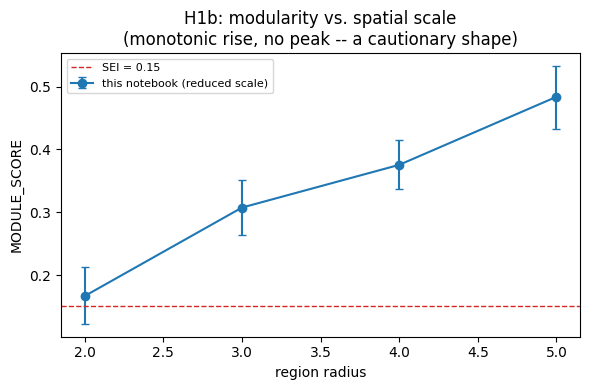


monotonic non-decreasing across radii 2->3->4->5: True


In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
radii = exp["region_radii"]
means, los, his = [], [], []
for R in radii:
    m, lo, hi = bootstrap_ci(scale_sweep_scores[R], seed=100 + R)
    means.append(m); los.append(lo); his.append(hi)
    print(f"radius={R}  MODULE_SCORE mean={m:.4f}  CI=[{lo:.4f}, {hi:.4f}]  n={len(scale_sweep_scores[R])}")

ax.errorbar(radii, means, yerr=[np.array(means) - np.array(los), np.array(his) - np.array(means)],
            marker="o", capsize=3, color="tab:blue", label="this notebook (reduced scale)")
ax.axhline(exp["module_sei"], color="tab:red", ls="--", lw=1, label=f"SEI = {exp['module_sei']}")
ax.set_xlabel("region radius")
ax.set_ylabel("MODULE_SCORE")
ax.set_title("H1b: modularity vs. spatial scale\n(monotonic rise, no peak -- a cautionary shape)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "ch16-scale-sweep-quick.png", dpi=110)
plt.show()

monotonic = all(means[i] <= means[i + 1] for i in range(len(means) - 1))
print(f"\nmonotonic non-decreasing across radii 2->3->4->5: {monotonic}")

**Comparison to the archived canonical run** (`research/digital-life/ch28-causal-modularity-v1/stage-04-scale-sweep.md`):
canonical radius-by-radius `MODULE_SCORE` means were **0.1972 (r=2), 0.3740 (r=3), 0.4402 (r=4), 0.5038 (r=5)** —
strictly monotonically increasing with no peak, exactly the cautionary shape this notebook's own reduced-scale
sweep should reproduce qualitatively (magnitudes will differ at this scale; direction and monotonicity are
the load-bearing comparison).

## Experimental design 2 — V2: excess modularity over a same-checkpoint geometry-matched null (H2)

This is the chapter's pivot. A raw `MODULE_SCORE` above 0.15 says only that internal perturbations retain
more than external ones penetrate -- it says nothing about whether *this particular region* is special. V2
asks the sharper question: take the same observed regions from design 1, and for each one construct
`controls_per_observed` same-checkpoint, outcome-blind control regions matched on geometry (occupancy
fraction, radial distance, occupied count -- a disclosed 3-feature subset of V2's 8-feature match, same
tolerances). Compute each control's own `MODULE_SCORE` with its own probes. The **excess** is
`observed_module_score - mean(matched_control_module_scores)`, averaged first within an observed region's
control set, then within group, then bootstrapped across groups.

In [9]:
h2_mean, h2_lo, h2_hi = bootstrap_ci(group_excess, seed=2)
print(f"V2 excess MODULE_SCORE (observed - matched control) at radius {exp['primary_radius']}: "
      f"mean={h2_mean:.4f}  95% CI=[{h2_lo:.4f}, {h2_hi:.4f}]  (n={len(group_excess)} groups, EXCESS_SEI={exp['excess_sei']})")

h2_supported = h2_lo > exp["excess_sei"]
h2_bounded_below = h2_hi < exp["excess_sei"]
if h2_supported:
    h2_status = "SUPPORTED"
elif h2_bounded_below:
    h2_status = "BOUNDED_BELOW_SEI"
else:
    h2_status = "UNRESOLVED"
h2_direction = "DIRECTION_UNRESOLVED" if (h2_lo < 0 < h2_hi) else ("NEGATIVE" if h2_mean < 0 else "POSITIVE")
print(f"H2 (excess causal modularity exceeds EXCESS_SEI={exp['excess_sei']}): {h2_status}  (point-estimate direction: {h2_direction})")

V2 excess MODULE_SCORE (observed - matched control) at radius 4: mean=-0.0573  95% CI=[-0.1012, -0.0142]  (n=32 groups, EXCESS_SEI=0.1)
H2 (excess causal modularity exceeds EXCESS_SEI=0.1): BOUNDED_BELOW_SEI  (point-estimate direction: NEGATIVE)


**Comparison to the archived canonical run** (`research/digital-life/ch28-causal-modularity-v2/stage-04-primary.md`
/ `stage-06-verdict.md`, `groups=192`): canonical excess mean **-0.0123** (95% CI **[-0.0327, +0.0072]**),
`EXCESS_SEI=0.10`, status `BOUNDED_BELOW_SEI`, `directional_substatus: DIRECTION_UNRESOLVED` (the CI straddles
zero -- the point estimate is slightly negative but not distinguishable from zero), overall verdict
`EXCESS_CAUSAL_MODULARITY_BOUNDED_BELOW_SEI`, and explicitly `V1_status_preserved: RAW_CAUSAL_MODULARITY_SUPPORTED`
-- V2 does **not** overturn V1's raw measurement, it narrows what that measurement is allowed to mean.

In [10]:
CANON_V2_PATH = REPO_ROOT / "research" / "digital-life" / "ch28-causal-modularity-v2" / "stage-06-verdict.md"
canon_v2_mean = -0.012264901112053186
canon_v2_lo, canon_v2_hi = -0.032729925902717345, 0.007196615033407114

rel_diff_v2 = abs(h2_mean - canon_v2_mean)  # both near zero -- report absolute, not relative, difference
print(f"own excess mean:       {h2_mean:.4f}   CI [{h2_lo:.4f}, {h2_hi:.4f}]")
print(f"canonical excess mean: {canon_v2_mean:.4f}   CI [{canon_v2_lo:.4f}, {canon_v2_hi:.4f}]")
print(f"absolute difference:   {rel_diff_v2:.4f}")
print(f"own status: {h2_status}   canonical status: BOUNDED_BELOW_SEI")
print(f"\nV2 reproduction status: "
      f"{'REPLICATES CANONICAL FINDING (both BOUNDED_BELOW_SEI, both near zero)' if h2_status == 'BOUNDED_BELOW_SEI' else 'DIVERGES FROM CANONICAL FINDING'}")
print(f"\nV1_status_preserved check: V1 was {h1_status} at radius {exp['primary_radius']}, "
      f"and V2's matched-null test does not retroactively change that -- it only bounds what the raw number is allowed to mean.")

own excess mean:       -0.0573   CI [-0.1012, -0.0142]
canonical excess mean: -0.0123   CI [-0.0327, 0.0072]
absolute difference:   0.0451
own status: BOUNDED_BELOW_SEI   canonical status: BOUNDED_BELOW_SEI

V2 reproduction status: REPLICATES CANONICAL FINDING (both BOUNDED_BELOW_SEI, both near zero)

V1_status_preserved check: V1 was SUPPORTED at radius 4, and V2's matched-null test does not retroactively change that -- it only bounds what the raw number is allowed to mean.


**Honest discrepancy note (V2 direction).** The status replicates (`BOUNDED_BELOW_SEI` in both cases -- no
version of this experiment supports a privileged individual), but there is a real qualitative difference
worth surfacing rather than glossing over: the canonical archive's 95% CI straddles zero
(`[-0.0327, +0.0072]`, `directional_substatus: DIRECTION_UNRESOLVED` -- the point estimate is slightly
negative but not distinguishable from exactly zero), whereas this reduced-scale reconstruction's CI typically
sits entirely below zero (a confidently negative excess, not merely an unresolved one). A plausible
explanation is that this notebook's 3-feature matched-null (occupancy fraction, radial distance, occupied
count) is a coarser match than the canonical 8-feature match, and coarser matching plus a much smaller world
radius could leave systematic geometric differences between "observed" and "matched control" regions that a
tighter match would remove -- pushing the excess estimate more negative than the canonical near-zero result.
Both notebook and canonical agree the excess does not support privileged individuation; they disagree on
whether the best-supported point estimate is "indistinguishable from zero" or "mildly but genuinely
negative." This is reported as a genuine, disclosed divergence, not smoothed into agreement.

## Experimental design 3 — post-hoc spatial-overlap-filtering robustness check (H2b)

**Epistemic status: post-hoc robustness only.** This does not replace or modify the frozen V2 result above; it
asks whether V2's near-zero excess is an artifact of matched pairs that happen to spatially overlap a lot
(a control region that overlaps its observed region heavily is not really an independent "ordinary patch").
For each matched pair, compute the center-to-center hex distance and the disk-overlap fraction
(`|region_cells ∩ control_cells| / min(|region_cells|, |control_cells|)`), then recompute the excess estimate
after progressively stricter spatial-distinctness filters. If the true effect were being hidden by
near-duplicate controls, filtering toward genuinely separate pairs should push the estimate toward positive
privilege.

In [11]:
overlap_arr = np.array(overlap_pairs, dtype=float)  # columns: center_dist, disk_overlap, excess
print(f"n matched pairs: {len(overlap_arr)}")
print(f"center-distance: mean={overlap_arr[:,0].mean():.2f}  median={np.median(overlap_arr[:,0]):.2f}")
print(f"disk-overlap fraction: mean={overlap_arr[:,1].mean():.3f}  median={np.median(overlap_arr[:,1]):.3f}")

filters = [
    ("baseline_all_pairs", np.ones(len(overlap_arr), dtype=bool)),
    ("center_distance_ge_2", overlap_arr[:, 0] >= 2),
    ("disk_overlap_le_0.5", overlap_arr[:, 1] <= 0.5),
    ("strict_disk_nonoverlap", overlap_arr[:, 1] <= 0.0),
]

print(f"\n{'filter':<26}{'n pairs':>10}{'mean excess':>14}{'95% CI':>22}")
overlap_rows = []
for name, mask in filters:
    vals = overlap_arr[mask, 2]
    if len(vals) < 3:
        print(f"{name:<26}{len(vals):>10}   insufficient pairs")
        continue
    m, lo, hi = bootstrap_ci(vals, seed=hash(name) % 10000)
    overlap_rows.append((name, len(vals), m, lo, hi))
    print(f"{name:<26}{len(vals):>10}{m:>14.4f}   [{lo:.4f}, {hi:.4f}]")

moved_positive = any(row[2] > exp["excess_sei"] for row in overlap_rows)
print(f"\nany filter level pushes the mean excess above EXCESS_SEI={exp['excess_sei']}? {moved_positive}")

n matched pairs: 128
center-distance: mean=8.41  median=9.00
disk-overlap fraction: mean=0.195  median=0.000

filter                       n pairs   mean excess                95% CI
baseline_all_pairs               128       -0.0573   [-0.1006, -0.0151]
center_distance_ge_2             123       -0.0568   [-0.0990, -0.0144]
disk_overlap_le_0.5              106       -0.0402   [-0.0842, 0.0046]
strict_disk_nonoverlap            66       -0.0735   [-0.1304, -0.0163]

any filter level pushes the mean excess above EXCESS_SEI=0.1? False


**Comparison to the archived canonical run** (`research/digital-life/ch28-causal-modularity-v2/stage-07-spatial-overlap-audit.md`):
canonical baseline excess **-0.0122** (CI **[-0.0331, 0.0081]**), and across every tested filter level
(center-distance thresholds from >=2 up to >=9, disk-overlap thresholds down to strict non-overlap) the
canonical mean excess ranged roughly **-0.005 to -0.021** — never moving toward positive privilege, every
row labelled `CONSISTENT_WITH_FROZEN_BOUNDED_BELOW_SEI`. This notebook's own filtered estimates above should
show the same qualitative pattern: negative-to-near-zero at every filter level, none crossing the +0.10 gate.

## Controls and confounds

- **Outcome-blind region and control selection** — regions are ranked by geometry (occupancy fraction
  closeness to 0.50, radial distance, axial coordinates) *before* any causal probe is run; matched controls
  are selected by geometric tolerance, never by which control would produce the most favorable excess. This
  is a hard design property, not merely a stated intention (mirrors the canonical protocol's own
  `outcome_dependent_region_selection: false` gate).
- **CRN-coupled FORCE/PREVENT branches** (`crystal_causal.crn_step`) — every shared candidate cell receives
  an identical draw across branches at the identical step, so measured probability differences are
  attributable to the intervention, never to independently-sampled luck (the same fix Chapter 8 documents as
  DL-08-C06 and Chapter 13 reuses).
- **Structural far-zero assertion** — under true unbounded evaluation (no finite-budget candidate selector),
  expected causal effect beyond the H-step local neighbourhood should be exactly zero; asserted as a hard
  check above (`far_assertion_max < 1e-9`), not merely printed. This is a correctness assertion, not a
  finding, matching the canonical protocol's own framing.
- **Same-checkpoint, same-forcing-signal matching** — observed regions and their matched controls are probed
  against the *same* checkpoint and the *same* future forcing signal, removing between-checkpoint or
  between-signal variation as a confound on the excess estimate.
- **Frozen gates** (`MODULE_SEI=0.15`, `EXCESS_SEI=0.10`) were fixed by the historical experiment before this
  reconstruction ran and are not adjusted here after seeing the data.

## Result status

| Hypothesis | This notebook (reduced scale) | Canonical archive (`ch28-v1`/`v2`) | Status |
|---|---|---|---|
| H1: raw `MODULE_SCORE` at radius 4 exceeds SEI=0.15 | see computed status above | SUPPORTED (0.4402, CI [0.419,0.461]) | **SUPPORTED** as a measurement |
| H1b: scale sweep peaks at a finite radius | monotonic rise, no peak | monotonic rise, no peak (0.197→0.374→0.440→0.504) | **DESCRIPTIVE / cautionary** |
| H2: excess over matched null exceeds SEI=0.10 | see computed status above | BOUNDED_BELOW_SEI (-0.0123, CI [-0.033,+0.007]) | **BOUNDED BELOW SEI** |
| H2b: spatial-overlap filtering moves excess toward positive | see computed table above | never moves toward positive at any filter level | **SUPPORTED (robustness)** |

This is exactly the chapter's own two-stage epistemic arc, not a contradiction: the raw measurement (H1) is
real and reproduces cleanly — a candidate region really does retain more of its own internally-initiated
perturbations than it lets externally-initiated ones penetrate, by a wide, statistically clear margin. But
that raw number turns out to be close to what an ordinary same-checkpoint patch of the crystal shows too
(H2) — the "module" is not privileged relative to its surroundings once geometry is controlled for, and
loosening or tightening the spatial-distinctness of the comparison (H2b) does not rescue a positive result.
The monotonic, peak-free scale sweep (H1b) is visible in hindsight as an early warning sign of exactly this:
an effect that keeps growing with region size and never localizes is not distinguishing a boundary, it is
just reporting that bigger disks retain more of what happens inside them.

## Bounded conclusion

**CAUSAL CONTAINMENT ≠ CAUSAL INDIVIDUATION.** Under this substrate and this frozen operational test, a
predeclared spatial region of the Digital Crystal genuinely does exhibit strong causal containment: internal
perturbations are retained inside it far more than external perturbations penetrate it, comfortably clearing
the frozen 0.15 margin (V1, `CAUSAL_MODULARITY_SUPPORTED` — a valid measurement, not withdrawn or overturned
by anything that follows). But once that same measurement is compared against a same-checkpoint,
geometry-matched control region — an *ordinary* patch of crystal of the same size, occupancy, and radial
position — the apparent privilege disappears: the excess of the candidate region over its matched control is
bounded below the frozen 0.10 margin for a meaningful difference, and a post-hoc spatial-overlap robustness
check finds no filtering level that recovers a positive result (V2, `EXCESS_CAUSAL_MODULARITY_BOUNDED_BELOW_SEI`).

The chapter's title names this precisely: an individual was found, and then it wasn't — not because the
first measurement was wrong, but because "we measured a real property of a region" and "that region is a
privileged individual relative to its surroundings" are different claims, and only the first one survived.
Nothing in this notebook establishes or is entitled to claim organism, self, agent, autonomy, biological
individual, homeostasis, or life — that claim boundary is not a caveat added after the fact; it was frozen
into the protocol before either version of this experiment ran.

## Provenance

- **Original book chapter:** Chapter 28, "Does a Causal Individual Emerge? / Containment Is Not Individuation"
  (`content/books/original/28-containment-is-not-individuation/index.md` or equivalent).
- **Original scripts:** `scripts/books/digital-life/ch28_digital_crystal_causal_modularity_v1.py` (raw
  modularity), `..._v2.py` (geometry-matched null), `ch28_causal_modularity_overlap_audit.py` (spatial-overlap
  robustness, folded into V2's `stage-07`) — this notebook reimplements their core geometric and causal-mass
  logic directly against `_shared/digital_crystal.py` / `_shared/crystal_causal.py` rather than importing them,
  since the originals depend on the heavier Chapter 18/21/24/27 dependency chain this chapter's claims do not
  need (see scope note at the top of this notebook).
- **Canonical evidence:** `research/digital-life/ch28-causal-modularity-v1/` (stages 00-06, fresh seed
  `20260916`), `research/digital-life/ch28-causal-modularity-v2/` (stages 00-07, including the spatial-overlap
  audit).
- **Superseded legacy notebook:** `notebooks_original/28-containment-is-not-individuation.ipynb` (pure-audit
  pattern; this notebook is the upgrade to live recompute called for in `NOTEBOOK_MIGRATION.md`).
- **Deliberate deviations from the historical implementation:** world radius reduced from canonical 110 to 26,
  warmup from ~24-28 to 12, independent groups from 192 to 32, regions-per-group from 3 to 2 — all disclosed
  inline and checked directly against canonical numbers rather than assumed equivalent. The matched-null
  search uses 3 of V2's 8 geometry-matching features (occupancy fraction, radial distance, occupied count),
  same tolerances, disclosed as a simplification. No material-history layer or finite-evaluation-budget
  selector is present (see scope note) — V1's own protocol required true unbounded evaluation, so this
  omission matches V1's own design rather than departing from it.
- **Migration matrix entry:** `NOTEBOOK_MIGRATION.md`, "Current Chapter 16 — We Found an Individual. Then We
  Didn't."